In [1]:
from spyplotter import ISMModel, HLymanA
from spyplotter import Spectrum

In [2]:
%matplotlib widget

# A general ISM line model

One can also specify an ISM model with an arbirtary amount of ions and lines. For each line, a wavelength, f-value (=oscillation strength) and the damping value needs to be given. 

For one ion, a number density in cm^-2 needs to be given as well. If only the density is given, a Lorentz profile will be computed for all the lines. If also a temperature and turbulent velocity are given, an additionally Doppler broadened Voigt profile is computed. 

## Read in the ISM model from a dictionary

In [3]:
ism_data = {
    "FeII": {
        "gas": {
            "n": 1e15,                 # cm^-2
#             "T": 80000,                 # K
#             "vturb": 5.0,              # km/s
#             "A": 55.845                # atomic mass
        },
        "lines": {
            1260: {
                "lambda": 1260.533,
                "f": 2.5e-2,
                "gamma": 2.1e8
            },
            1608: {
                "lambda": 1608.451,
                "f": 5.8e-1,
                "gamma": 320000000
            },
        }
    },

    "MgII": {
        "gas": {
            "n":2e16,
            "T": 70000,
            "vturb": 3.0,
            "A": 24.305
        },
        "lines": {
            2796: {
                "lambda": 2796.352,
                "f": 0.615,
                "gamma": 2.6e8
            },
            2803: {
                "lambda": 2803.531,
                "f": 0.305,
                "gamma": 2.6e8
            }
        }
    }
}

In [4]:
ism = ISMModel(ism_data)

spyplotter.spec_tools.unit_checks - INFO - No unit for temperature specified. Thus assuming cm^2.
spyplotter.spec_tools.unit_checks - INFO - No unit for x specified. Thus assuming Angstroem.
spyplotter.ism_lines - INFO - No unit for gamma specified. Thus assuming 1/s.
spyplotter.spec_tools.unit_checks - INFO - No unit for x specified. Thus assuming Angstroem.
spyplotter.ism_lines - INFO - No unit for gamma specified. Thus assuming 1/s.
spyplotter.spec_tools.unit_checks - INFO - No unit for temperature specified. Thus assuming cm^2.
spyplotter.spec_tools.unit_checks - INFO - No unit for temperature specified. Thus assuming Kelvin.
spyplotter.spec_tools.unit_checks - INFO - No unit for vrad specified. Thus assuming km/s.
spyplotter.spec_tools.unit_checks - INFO - No unit for x specified. Thus assuming Angstroem.
spyplotter.ism_lines - INFO - No unit for gamma specified. Thus assuming 1/s.
spyplotter.spec_tools.unit_checks - INFO - No unit for x specified. Thus assuming Angstroem.
spyplot

## Write and read the ISM model from a yaml file 

In [5]:
ism.to_yaml('ism_model4.yaml')

In [6]:
ism2 = ISMModel.from_yaml('ism_model4.yaml')

spyplotter.spec_tools.unit_checks - INFO - No unit for temperature specified. Thus assuming cm^2.
spyplotter.spec_tools.unit_checks - INFO - No unit for temperature specified. Thus assuming Kelvin.
spyplotter.spec_tools.unit_checks - INFO - No unit for vrad specified. Thus assuming km/s.
spyplotter.spec_tools.unit_checks - INFO - No unit for vrad specified. Thus assuming km/s.
spyplotter.spec_tools.unit_checks - INFO - No unit for x specified. Thus assuming Angstroem.
spyplotter.ism_lines - INFO - No unit for gamma specified. Thus assuming 1/s.
spyplotter.spec_tools.unit_checks - INFO - No unit for x specified. Thus assuming Angstroem.
spyplotter.ism_lines - INFO - No unit for gamma specified. Thus assuming 1/s.
spyplotter.spec_tools.unit_checks - INFO - No unit for temperature specified. Thus assuming cm^2.
spyplotter.spec_tools.unit_checks - INFO - No unit for temperature specified. Thus assuming Kelvin.
spyplotter.spec_tools.unit_checks - INFO - No unit for vrad specified. Thus assu

## Plot all the ISM lines

When not specifying a spectrum, it assumes a continuum of a normalized spectrum with flux 1 over the full range. The ISM model can be converted to a LineIdentifier and also be plot. To the line name, an extra tag like (ISM) can be added to clarify in a spectrum that these are ISM lines

In [7]:
li = ism.to_LineIdentifier(suffix_line_name = '(ISM)')

spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed


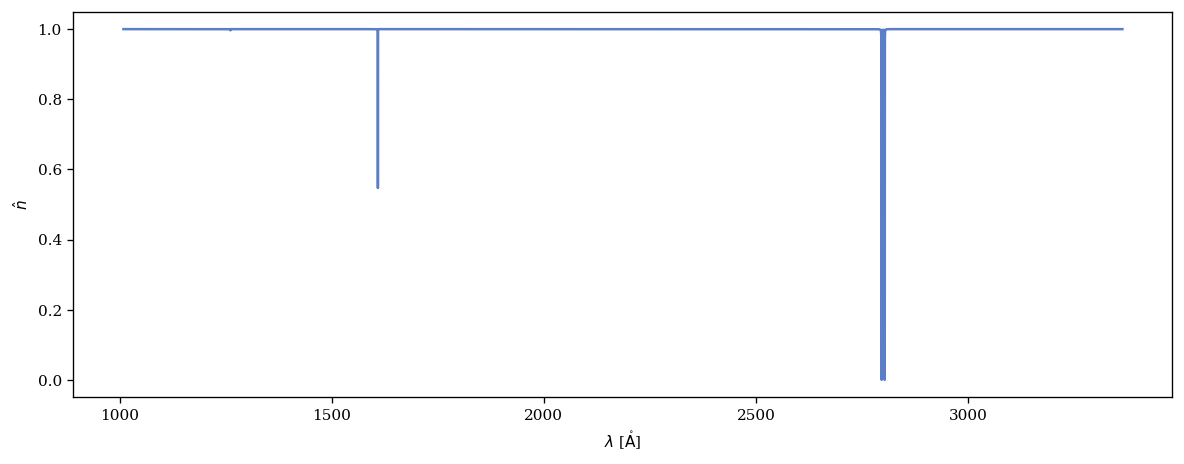

In [8]:
ax = ism.plot()
#li.plot(ax=ax)

It is also possible to add the ISM lines to a Spectrum object

In [9]:
sp = Spectrum.from_powr(
    filepath='../tests/test_data/T33_logg4.0_Mdot-8.5_logL4.72_v1994_vmic8_Z0.1/formal.plot',
    keywords=['UV'],
    dataset=1
)

spyplotter.spectrum - INFO - No flux unit specified and no signs for y units detected. Thus assuming normalized spectum.
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spec_tools.unit_checks - INFO - No unit for vrad specified. Thus assuming km/s.


spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: 
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.line_identification - WARNING - Text out of ylim, automatically adapting ymax now from ymax_old=1.41 to ymax_new=1.81


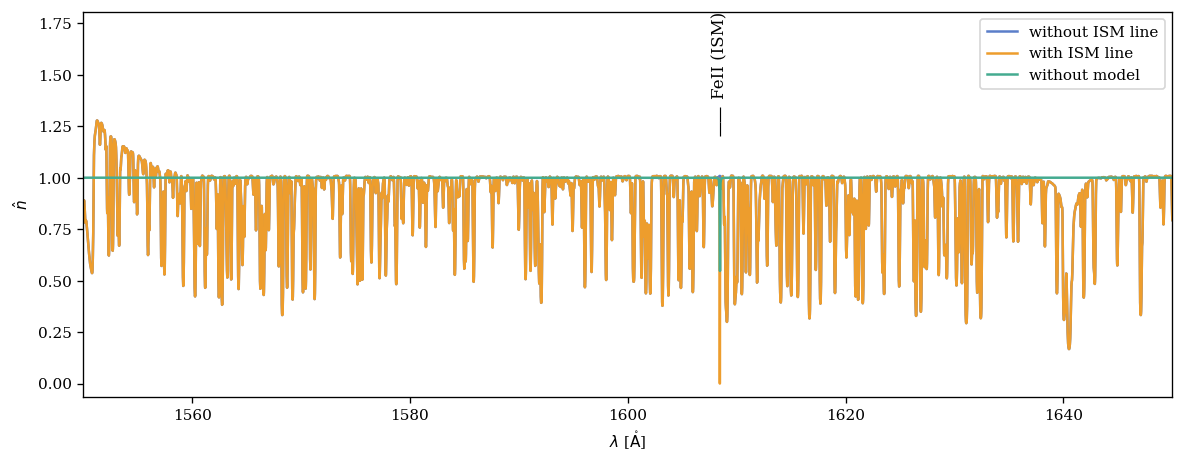

In [10]:
ax = sp.plot(label='without ISM line')
ax.set_xlim(1550,1650)
ism.plot(ax=ax,sp=sp,label='with ISM line')
ism.plot(ax=ax,label='without model')
li.plot(ax=ax)
ax.legend()

# An ISM model for Lyman Alpha lines

In [11]:
hlymana = HLymanA(ebv=0.1)
li_hly = hlymana.to_LineIdentifier()

#Original model spectrum
sp = Spectrum.from_powr(
    filepath='../tests/test_data/T33_logg4.0_Mdot-8.5_logL4.72_v1994_vmic8_Z0.1/formal.plot',
    keywords=['UV'],
    dataset=1
)

spyplotter.spectrum - INFO - No flux unit specified and no signs for y units detected. Thus assuming normalized spectum.
spyplotter.spectrum - INFO - As no unit for x was specified, Angstrom are assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spec_tools.unit_checks - INFO - No unit for vrad specified. Thus assuming km/s.


spyplotter.spectrum - INFO - Keeping units of x: Angstrom
spyplotter.spectrum - INFO - Keeping units of y: 
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.spectrum - INFO - As no unit for y was given, a normalized spectrum is assumed
spyplotter.line_identification - WARNING - Text out of ylim, automatically adapting ymax now from ymax_old=1.41 to ymax_new=1.54


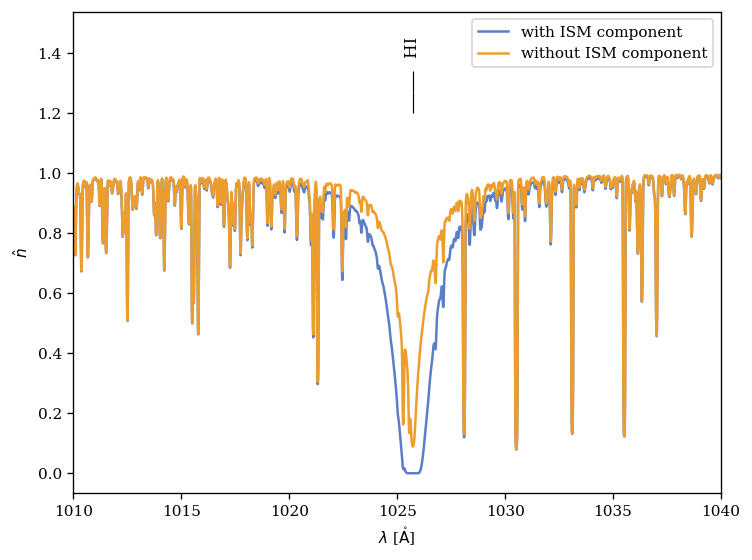

In [14]:
ax=hlymana.plot(sp=sp,label='with ISM component')
sp.plot(ax=ax,label='without ISM component')
ax.set_xlim(1010,1040.0)
li_hly.plot(ax=ax)
ax.legend()